In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians
from matplotlib.patches import ConnectionStyle
import matplotlib.image as mpimg

In [32]:
housing = pd.read_csv('data/housing_data.csv', encoding='gbk')

/tmp/ipykernel_1036395/2412776476.py:1: DtypeWarning: Columns (2,10,11,13) have mixed types. Specify dtype option on import or set low_memory=False.
  housing = pd.read_csv('data/housing_data.csv', encoding='gbk')


In [2]:
housing.shape

(318851, 22)

In [3]:
housing.head(5)

,Unnamed: 0,url,id,Lng,Lat,Cid,tradeTime,DOM,totalPrice,square,...,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district
0,0,https://bj.lianjia.com/chengjiao/101084782030....,101084782030,116.475489,40.019520,1111027376244,2016-08-09,1464.0,415.0,131.00,...,1,1,高 26,2005,3,6,0.217,1.0,1.0,7
1,1,https://bj.lianjia.com/chengjiao/101086012217....,101086012217,116.453917,39.881534,1111027381879,2016-07-28,903.0,575.0,132.38,...,1,2,高 22,2004,4,6,0.667,1.0,0.0,7
2,2,https://bj.lianjia.com/chengjiao/101086041636....,101086041636,116.561978,39.877145,1111040862969,2016-12-11,1271.0,1030.0,198.00,...,1,3,中 4,2005,3,6,0.500,1.0,0.0,7
3,3,https://bj.lianjia.com/chengjiao/101086406841....,101086406841,116.438010,40.076114,1111043185817,2016-09-30,965.0,297.5,134.00,...,1,1,底 21,2008,1,6,0.273,1.0,0.0,6
4,4,https://bj.lianjia.com/chengjiao/101086920653....,101086920653,116.428392,39.886229,1111027381174,2016-08-28,927.0,392.0,81.00,...,1,1,中 6,1960,2,2,0.333,0.0,1.0,1


In [4]:
housing_dropped = housing.drop(['url','Cid', 'id', 'Unnamed: 0'], axis=1)

In [5]:
housing_null = housing_dropped.isnull().sum().to_frame()

<Axes: >

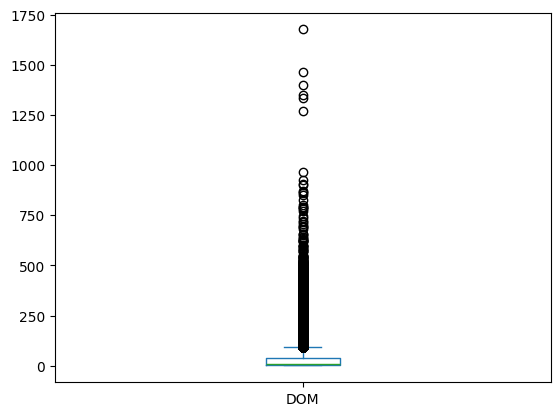

In [6]:
housing_dropped.DOM.plot(kind = 'box')

In [7]:
housing_no_missing = housing_dropped.copy()

In [8]:
housing_no_missing['DOM'] = housing_no_missing['DOM'].fillna(housing_no_missing['DOM'].mode()[0])
housing_no_missing = housing_no_missing.dropna(subset=['elevator', 'subway'], how='any')

In [9]:
housing_no_missing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 318819 entries, 0 to 318850
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Lng                  318819 non-null  float64
 1   Lat                  318819 non-null  float64
 2   tradeTime            318819 non-null  object 
 3   DOM                  318819 non-null  float64
 4   totalPrice           318819 non-null  float64
 5   square               318819 non-null  float64
 6   livingRoom           318819 non-null  object 
 7   drawingRoom          318819 non-null  object 
 8   kitchen              318819 non-null  int64  
 9   bathRoom             318819 non-null  object 
 10  floor                318819 non-null  object 
 11  constructionTime     318819 non-null  object 
 12  renovationCondition  318819 non-null  int64  
 13  buildingStructure    318819 non-null  int64  
 14  ladderRatio          318819 non-null  float64
 15  elevator             3

In [11]:
housing_categorical = housing_no_missing.copy()

housing_categorical[['elevator', 'subway', 'buildingStructure', 'renovationCondition']] = housing_no_missing[['elevator', 'subway', 'buildingStructure', 'renovationCondition']].replace({'elevator' : {1: 'has elevator', 0: 'no elevator'}, 'subway': {1: 'has subway', 0: 'no subway'}, 'buildingStructure': {1: 'unknown', 2: 'mixed', 3:'brick and wood', 4:'concrete', 5:'steel', 6:'steel-concrete composite'}, 'renovationCondition' : {1:'other', 2:'rough', 3:'Simplicity', 4:'hardcover'}})

housing_categorical.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,高 26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,高 22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7
2,116.561978,39.877145,2016-12-11,1271.0,1030.0,198.00,3,2,1,3,中 4,2005,Simplicity,steel-concrete composite,0.500,has elevator,no subway,7
3,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,底 21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6
4,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,中 6,1960,rough,mixed,0.333,no elevator,has subway,1


In [12]:
housing_categorical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 318819 entries, 0 to 318850
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Lng                  318819 non-null  float64
 1   Lat                  318819 non-null  float64
 2   tradeTime            318819 non-null  object 
 3   DOM                  318819 non-null  float64
 4   totalPrice           318819 non-null  float64
 5   square               318819 non-null  float64
 6   livingRoom           318819 non-null  object 
 7   drawingRoom          318819 non-null  object 
 8   kitchen              318819 non-null  int64  
 9   bathRoom             318819 non-null  object 
 10  floor                318819 non-null  object 
 11  constructionTime     318819 non-null  object 
 12  renovationCondition  318819 non-null  object 
 13  buildingStructure    318819 non-null  object 
 14  ladderRatio          318819 non-null  float64
 15  elevator             3

In [13]:
print('constructionTime : ',housing_categorical.constructionTime.unique())
print('floor : ',housing_categorical.floor.unique())

constructionTime :  ['2005' '2004' '2008' '1960' '1997' '2009' '2006' '1991' '2001' '1990'
 '2011' '2000' '1998' '2010' '1996' '1993' '2002' '未知' '2012' '1989'
 '2003' '2007' '1994' '1984' '1992' '2014' '1985' '2013' '1999' '1979'
 '1981' '1976' '1982' '1975' '1983' '1986' '1995' '1965' '1988' '1987'
 '2015' '1955' '1980' '1978' '1958' '1970' '1956' '1977' '1964' '1963'
 '1967' '2016' '1974' '1973' '1959' '1954' '1962' '1966' '1957' '1944'
 '1972' '1971' '1953' '1968' '1961' '1950' '1952' '1933' '1969' '1906'
 '1934' '1914']
floor :  ['高 26' '高 22' '中 4' '底 21' '中 6' '中 8' '高 6' '高 10' '中 23' '底 11' '底 3'
 '高 24' '低 23' '中 19' '高 18' '低 25' '中 12' '中 14' '中 30' '中 27' '中 5'
 '低 18' '底 28' '中 11' '低 9' '顶 7' '顶 27' '低 6' '中 17' '顶 6' '中 24' '中 15'
 '底 5' '中 29' '顶 19' '顶 5' '中 9' '低 22' '顶 18' '低 16' '高 13' '高 9' '高 17'
 '底 6' '中 28' '低 26' '底 15' '高 16' '底 2' '低 7' '中 13' '低 33' '底 14' '高 15'
 '底 4' '顶 11' '中 32' '顶 16' '底 18' '顶 17' '低 14' '低 10' '底 20' '高 12'
 '低 31' '低 30' '低 19' '低

In [14]:
housing_construction = housing_categorical.copy()

housing_construction = housing_construction[housing_construction['constructionTime'].isin(['unknown', '未知']) == False].assign(constructionTime=lambda x: x['constructionTime'].astype(int))

housing_construction.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,高 26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,高 22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7
2,116.561978,39.877145,2016-12-11,1271.0,1030.0,198.00,3,2,1,3,中 4,2005,Simplicity,steel-concrete composite,0.500,has elevator,no subway,7
3,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,底 21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6
4,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,中 6,1960,rough,mixed,0.333,no elevator,has subway,1


In [15]:
housing_floor = housing_construction.copy()

housing_floor['floor'] = housing_floor['floor'].str.extract('(\d+)').astype(int)

housing_floor.head()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1036395/2944374478.py:3: SyntaxWarning: invalid escape sequence '\d'
  housing_floor['floor'] = housing_floor['floor'].str.extract('(\d+)').astype(int)


,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7
2,116.561978,39.877145,2016-12-11,1271.0,1030.0,198.00,3,2,1,3,4,2005,Simplicity,steel-concrete composite,0.500,has elevator,no subway,7
3,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6
4,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,6,1960,rough,mixed,0.333,no elevator,has subway,1


In [16]:
housing_floor.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299536 entries, 0 to 318849
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Lng                  299536 non-null  float64
 1   Lat                  299536 non-null  float64
 2   tradeTime            299536 non-null  object 
 3   DOM                  299536 non-null  float64
 4   totalPrice           299536 non-null  float64
 5   square               299536 non-null  float64
 6   livingRoom           299536 non-null  object 
 7   drawingRoom          299536 non-null  object 
 8   kitchen              299536 non-null  int64  
 9   bathRoom             299536 non-null  object 
 10  floor                299536 non-null  int64  
 11  constructionTime     299536 non-null  int64  
 12  renovationCondition  299536 non-null  object 
 13  buildingStructure    299536 non-null  object 
 14  ladderRatio          299536 non-null  float64
 15  elevator             2

<Axes: >

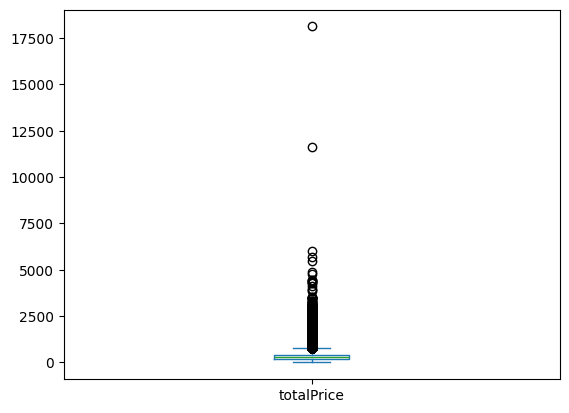

In [17]:
housing_floor.totalPrice.plot(kind = 'box')

In [18]:
housing_no_outlier = housing_floor[(housing_floor['totalPrice'] >= (housing_floor['totalPrice'].quantile(0.25) - 1.5 * (housing_floor['totalPrice'].quantile(0.75) - housing_floor['totalPrice'].quantile(0.25)))) & (housing_floor['totalPrice'] <= (housing_floor['totalPrice'].quantile(0.75) + 1.5 * (housing_floor['totalPrice'].quantile(0.75) - housing_floor['totalPrice'].quantile(0.25))))]

print('Number of removed outliers : ', housing_floor.shape[0] - housing_no_outlier.shape[0])

Number of removed outliers :  14496


<Axes: >

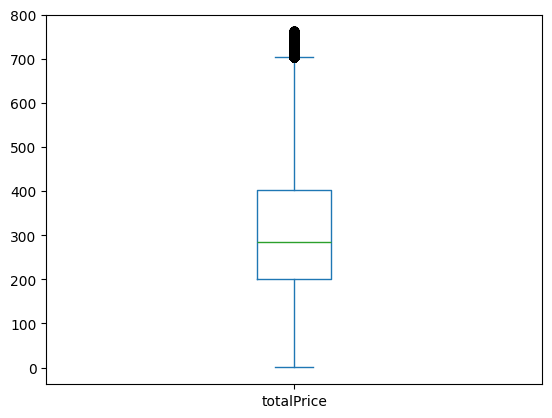

In [19]:
housing_no_outlier.totalPrice.plot(kind = 'box')

In [22]:
capital_Lng = radians(116.4074)
capital_Lat = radians(39.9042)

housing_capital = housing_no_outlier.copy()
housing_capital['distanceToCapital'] = np.arccos(np.sin(capital_Lat) * np.sin(np.radians(housing_capital['Lat'])) + np.cos(capital_Lat) * np.cos(np.radians(housing_capital['Lat'])) * np.cos(np.radians(housing_capital['Lng']) - capital_Lng)) * 6371.0088
housing_capital.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district,distanceToCapital
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7,14.074996
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7,4.701224
3,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6,19.293041
4,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,6,1960,rough,mixed,0.333,no elevator,has subway,1,2.683335
5,116.466280,39.991363,2016-07-22,861.0,275.6,53.00,1,0,1,1,8,2005,Simplicity,steel-concrete composite,0.333,has elevator,no subway,7,10.914652


In [23]:
housing_PPS = housing_capital.copy()

housing_PPS['pricePerSquare'] = (housing_PPS['totalPrice'] / housing_PPS['square']) * 1000

housing_PPS.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district,distanceToCapital,pricePerSquare
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7,14.074996,3167.938931
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7,4.701224,4343.556428
3,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6,19.293041,2220.149254
4,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,6,1960,rough,mixed,0.333,no elevator,has subway,1,2.683335,4839.506173
5,116.466280,39.991363,2016-07-22,861.0,275.6,53.00,1,0,1,1,8,2005,Simplicity,steel-concrete composite,0.333,has elevator,no subway,7,10.914652,5200.000000


/tmp/ipykernel_1036395/60454985.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  housing_PPS.hist(ax = ax, bins = 20);


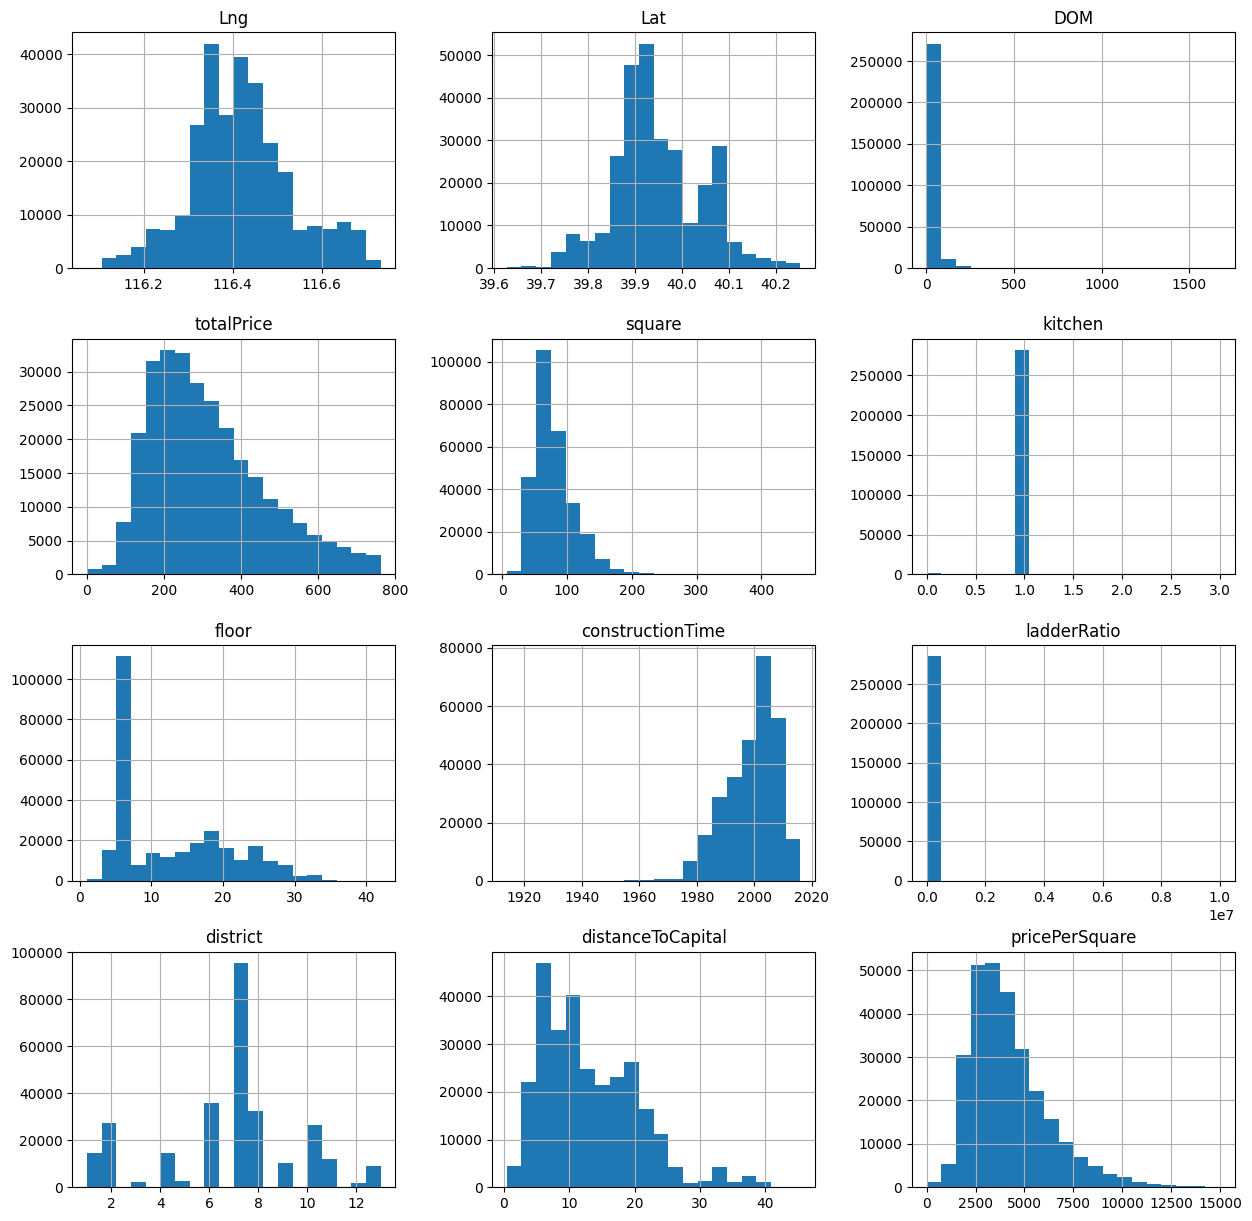

In [24]:
fig , ax = plt.subplots()
fig.set_size_inches(15,15)
housing_PPS.hist(ax = ax, bins = 20);

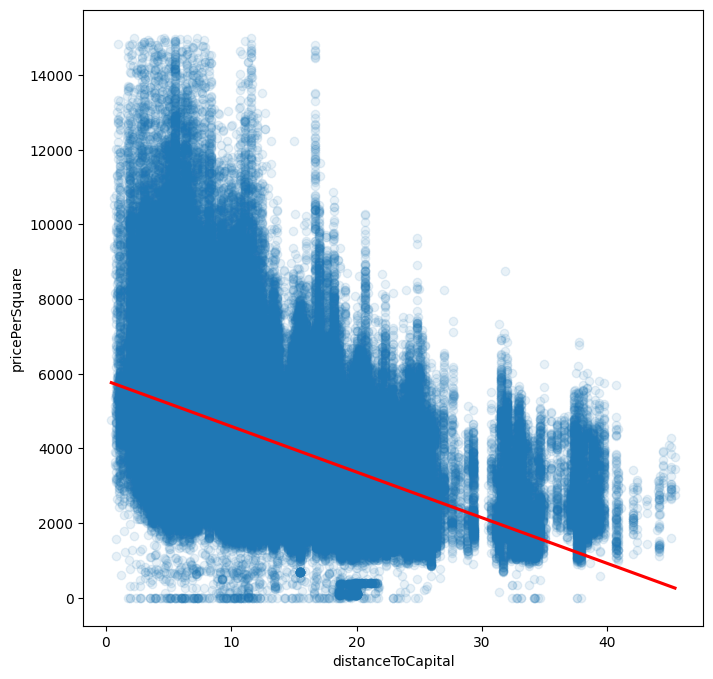

In [25]:
fig , ax = plt.subplots()
fig.set_size_inches(8,8)

sns.regplot(ax = ax, data = housing_PPS, x = 'distanceToCapital', y = 'pricePerSquare', 
                   line_kws={'color':'red'}, scatter_kws= {'alpha': 0.1});

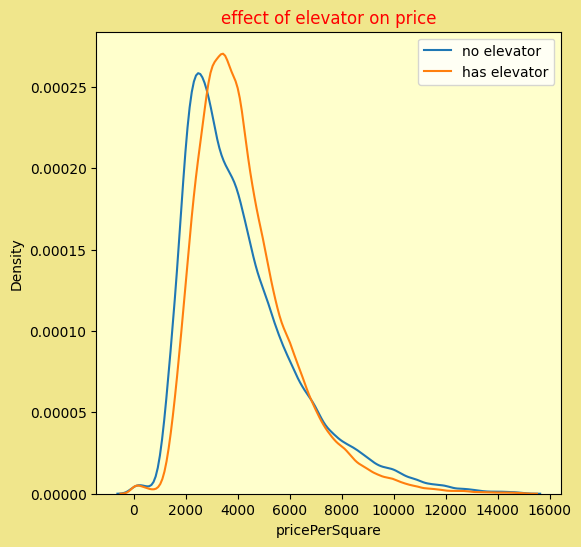

In [26]:
fig, ax = plt.subplots()
fig.set_size_inches(6,6)
fig.patch.set_facecolor('khaki')
ax.set_facecolor('#ffffcc')
ax.set_title('effect of elevator on price', color='red')
sns.kdeplot(housing_PPS[housing_PPS['elevator'] == 'no elevator']['pricePerSquare'], ax=ax, label='no elevator')
sns.kdeplot(housing_PPS[housing_PPS['elevator'] == 'has elevator']['pricePerSquare'], ax=ax, label='has elevator')
ax.legend()

In [27]:
housing_extended = housing_PPS.copy()

In [28]:
housing_sample = housing_extended.iloc[:-100:100]
housing_sample.shape

(2850, 20)

Text(0.5, 1.0, 'scatter plot')

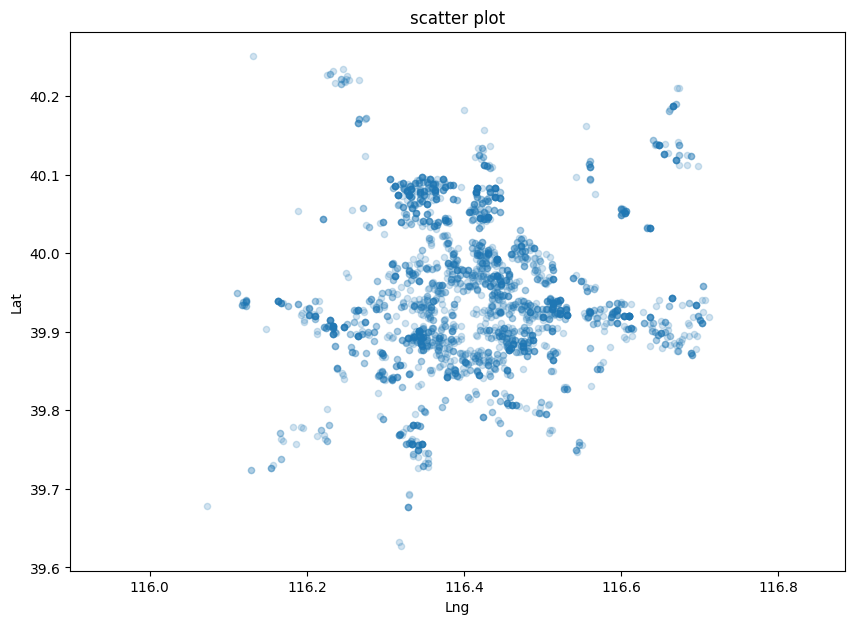

In [29]:
fig1 , ax1 = plt.subplots()
fig1.set_size_inches(10,7)

housing_sample.plot(x='Lng', y='Lat', ax=ax1, kind='scatter', alpha=0.2)
ax1.axis('equal')
ax1.set_title('scatter plot')

(np.float64(116.04057284999999),
 np.float64(116.74327815),
 np.float64(39.5958495),
 np.float64(40.281820499999995))

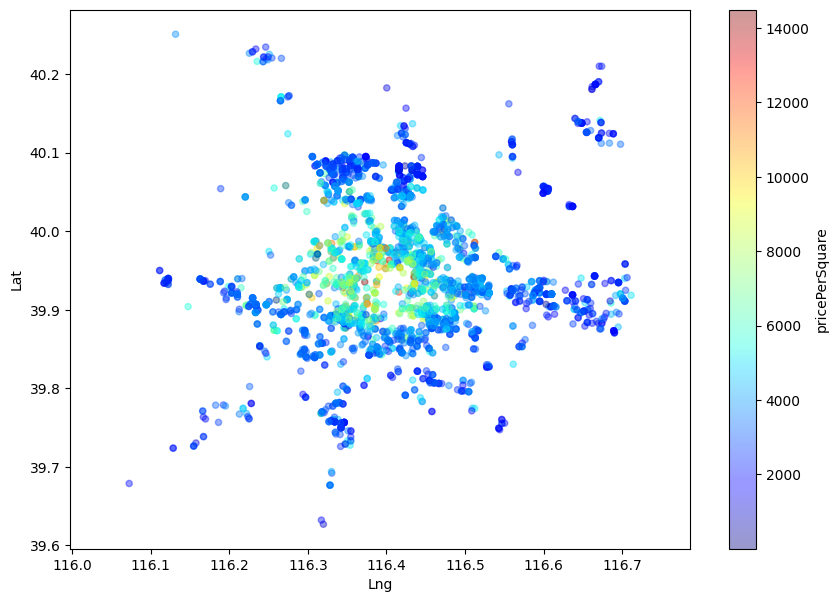

In [30]:
fig2 , ax2 = plt.subplots()
fig2.set_size_inches(10,7)

housing_sample.plot(x='Lng', y='Lat', ax=ax2, kind='scatter', alpha=0.4,
                    c='pricePerSquare', cmap=plt.get_cmap("jet"), colorbar=True)

ax2.axis('equal')

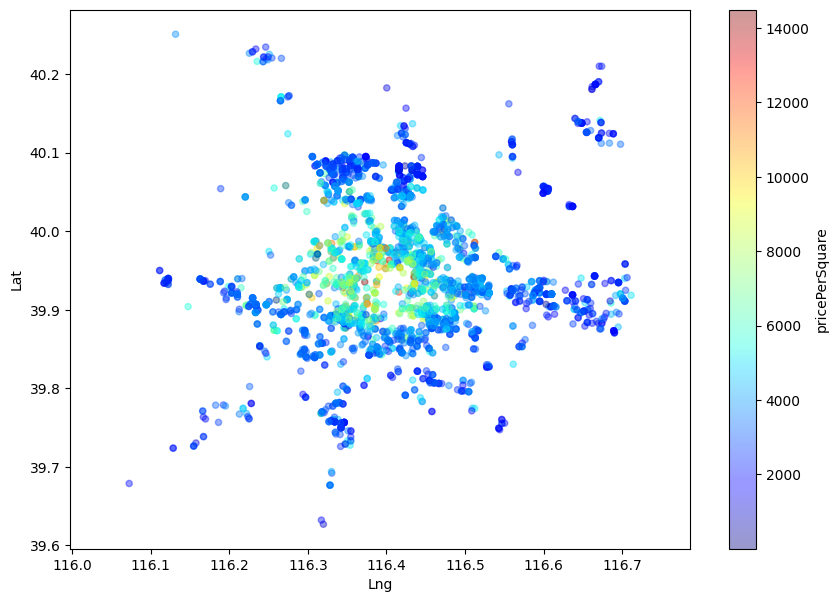

In [33]:
connectionstyle = ConnectionStyle("Arc3", rad=0.3)
ax2.annotate(xy = (116.40, 116.40), text = 'center of beijing', xytext = (39.65, 116.6), arrowprops=dict(arrowstyle="fancy",connectionstyle=connectionstyle))
fig2

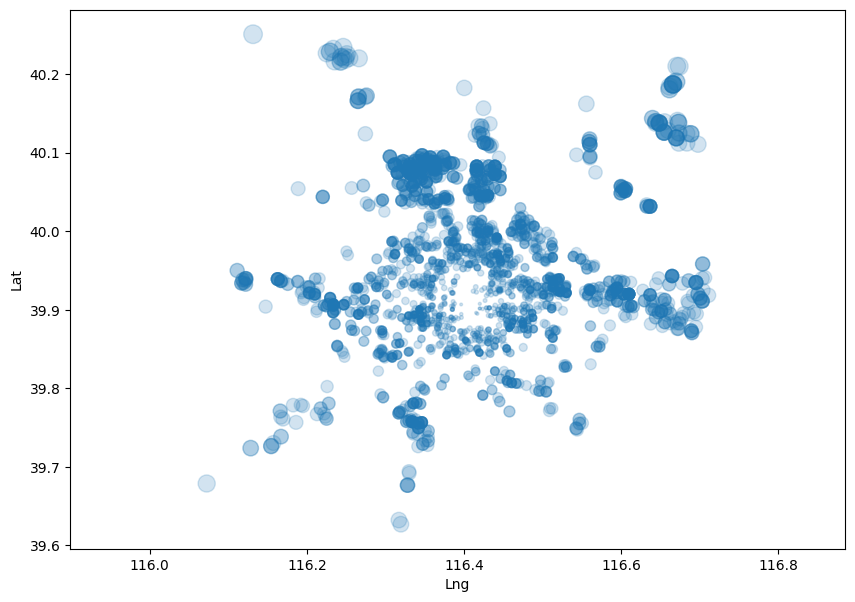

In [35]:
fig3 , ax3 = plt.subplots()
fig3.set_size_inches(10,7)

housing_sample.plot(x = 'Lng' , y ='Lat' ,ax = ax3, kind = 'scatter', alpha = 0.2,\
    s = housing_sample['distanceToCapital'] * 4)

ax3.axis('equal');

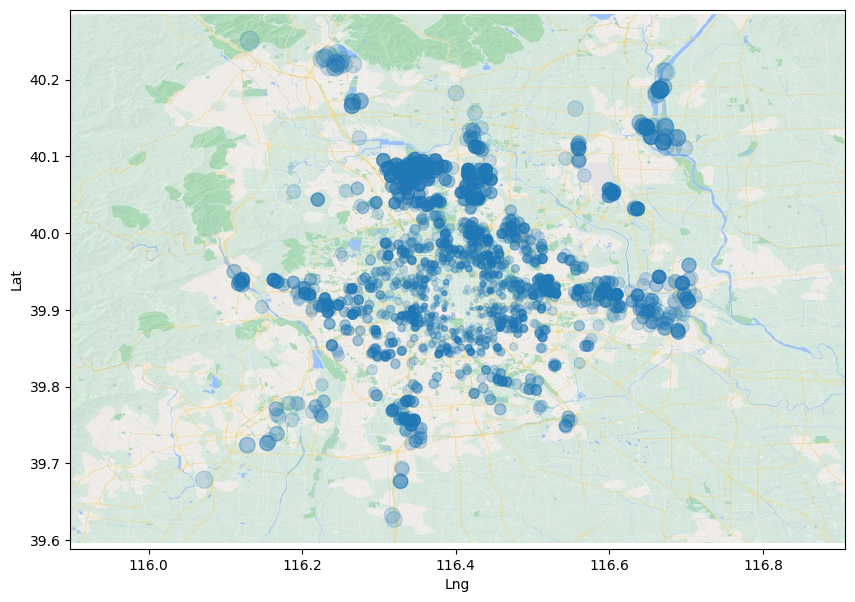

In [38]:
beijing_img = mpimg.imread('map1.jpg')
ax3.imshow(beijing_img, extent=[115.89777890444654, 116.90711309555346, 39.5957436, 40.2840444])
fig3

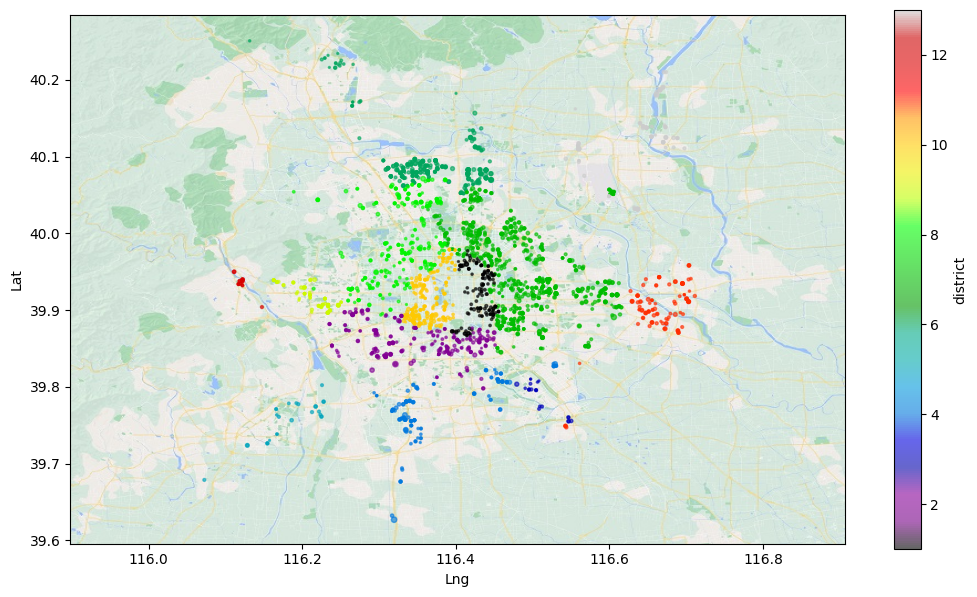

In [39]:
fig4, ax4 = plt.subplots()
fig4.set_size_inches(12.5,7)
housing_sample.plot(x = 'Lng' , y ='Lat' ,ax = ax4, kind = 'scatter', alpha = 0.6, c='district', cmap=plt.get_cmap("nipy_spectral"), s = housing_sample['square'] / 20, );
beijing_img = mpimg.imread('map1.jpg')
ax4.imshow(beijing_img, extent=[115.89777890444654, 116.90711309555346, 39.5957436, 40.2840444])
fig4;

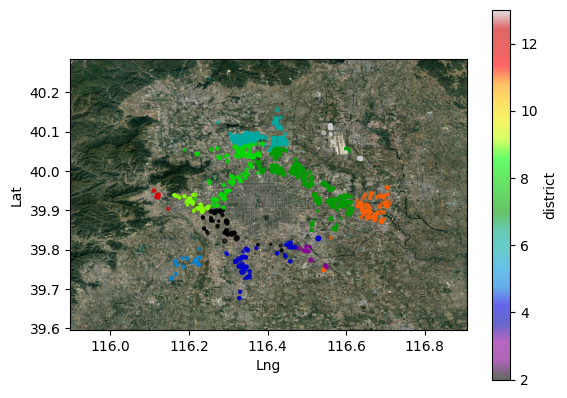

In [40]:
fig5, ax5 = plt.subplots()
fig4.set_size_inches(12.5,7)
housing_sample[(housing_sample['distanceToCapital'] > 10) & (housing_sample['distanceToCapital'] < 30)].plot(x = 'Lng' , y ='Lat' ,ax = ax5, kind = 'scatter', alpha = 0.6, c='district', cmap=plt.get_cmap("nipy_spectral"), s = housing_sample[(housing_sample['distanceToCapital'] > 10) & (housing_sample['distanceToCapital'] < 30)]['square'] / 20, );
beijing_img = mpimg.imread('map2.jpg')
ax5.imshow(beijing_img, extent=[115.89777890444654, 116.90711309555346, 39.5957436, 40.2840444])
fig5;

In [42]:
districts_df = housing_extended.assign(buildingAge=2021 - housing_extended['constructionTime'], elevator_flag=(housing_extended['elevator'] == 'has elevator').astype(int),subway_flag=(housing_extended['subway'] == 'has subway').astype(int)).groupby('district').agg({'pricePerSquare': 'mean', 'elevator_flag': lambda x: 100 * x.mean(), 'subway_flag': lambda x: 100 * x.mean(), 'square': 'mean', 'buildingAge': 'mean','buildingStructure': lambda x: x.mode().iloc[0] }).rename(columns={'pricePerSquare': 'pricePerSquare mean','elevator_flag': '% houses with elevator','subway_flag': '% houses with subway',  'square': 'square mean','buildingAge': 'building age mean','buildingStructure': 'frequent buildingStructure'})
districts_df.head()

,pricePerSquare mean,% houses with elevator,% houses with subway,square mean,building age mean,frequent buildingStructure
district,,,,,,
1,5981.774965,56.216550,93.488404,67.047856,25.151709,steel-concrete composite
2,3805.924811,68.647623,61.825544,76.951352,20.639123,steel-concrete composite
3,3130.333142,66.636691,47.032374,92.071484,15.494604,steel-concrete composite
4,2999.928821,39.983398,43.027117,86.322272,18.324364,mixed
5,2841.761483,80.077031,39.005602,89.297990,11.271359,steel-concrete composite


In [43]:
housing_extended['tradeTime'] = pd.to_datetime(housing_extended['tradeTime'])
housing_extended.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district,distanceToCapital,pricePerSquare
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7,14.074996,3167.938931
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7,4.701224,4343.556428
3,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6,19.293041,2220.149254
4,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,6,1960,rough,mixed,0.333,no elevator,has subway,1,2.683335,4839.506173
5,116.466280,39.991363,2016-07-22,861.0,275.6,53.00,1,0,1,1,8,2005,Simplicity,steel-concrete composite,0.333,has elevator,no subway,7,10.914652,5200.000000


/tmp/ipykernel_1036395/715788320.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  year_avg = filtered_df1 [filtered_df1 .index.year >= 2010].resample('M')['pricePerSquare'].mean()


<Axes: title={'center': 'pricePerSquare over time'}, xlabel='tradeTime', ylabel='pricePerSquare'>

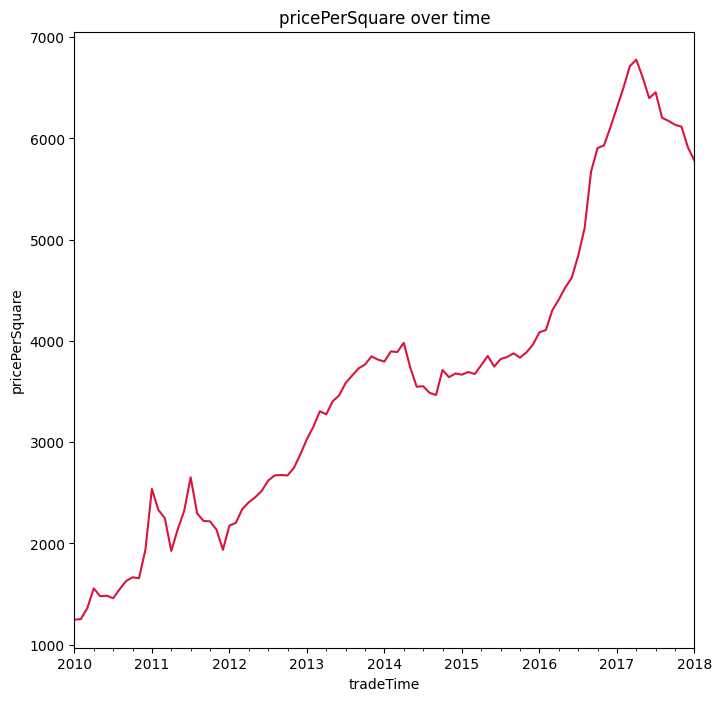

In [44]:
fig1 , ax1 = plt.subplots(figsize = (8,8))
ax1.set_title('pricePerSquare over time')
filtered_df1 = housing_extended.set_index('tradeTime', inplace=False)
year_avg = filtered_df1 [filtered_df1 .index.year >= 2010].resample('M')['pricePerSquare'].mean()
ax1.set_ylabel('pricePerSquare')
year_avg.plot(ax=ax1, color='crimson')

/tmp/ipykernel_1036395/382091862.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  filtered_df = housing_extended[(housing_extended['tradeTime'].dt.year >= 2010)].resample('3M', on='tradeTime').apply(lambda x: (x['distanceToCapital'] < 15.0).sum())


<Axes: title={'center': 'center city house trades over time'}, xlabel='tradeTime', ylabel='frequency'>

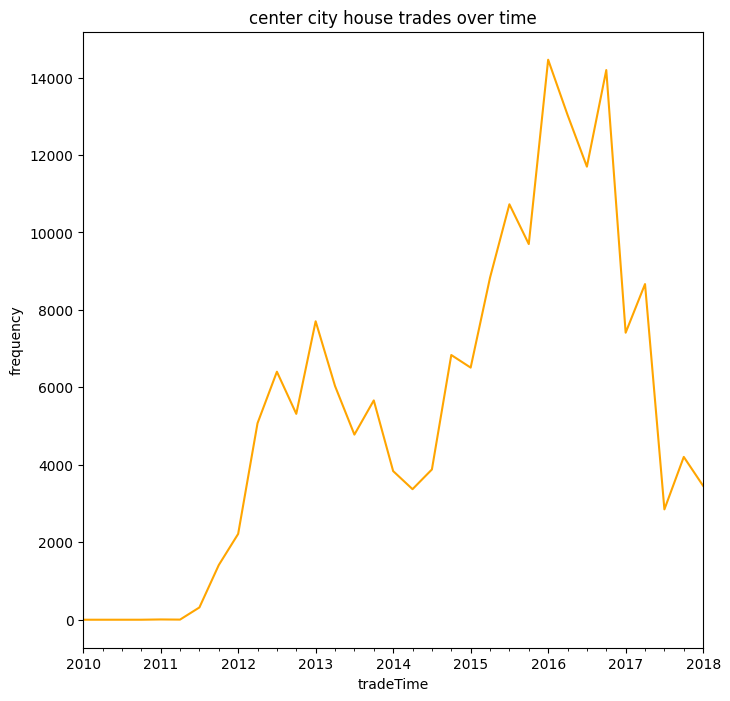

In [45]:
fig2 , ax2 = plt.subplots(figsize = (8,8))
ax2.set_title('center city house trades over time')
filtered_df = housing_extended[(housing_extended['tradeTime'].dt.year >= 2010)].resample('3M', on='tradeTime').apply(lambda x: (x['distanceToCapital'] < 15.0).sum())
ax2.set_ylabel('frequency')
filtered_df.plot(ax=ax2, color='orange')